# Retrieval Evaluation: Ingestion ? Processing ? Retrieval

This notebook measures retrieval quality on the project?s local research-paper corpus using the production pipeline from PDF ingestion through section-aware processing and retrieval.

The default run is offline: local PDFs, a locally cached MiniLM embedder, in-memory Qdrant, and a deterministic proxy cross-encoder. No generation pipeline is required.


- The production pipeline ingested **5 local PDFs**, generated and indexed **530 section-aware chunks**, and evaluated **10 golden queries**.
- Dense, sparse, hybrid, proxy-reranked, and MMR configurations all achieved **Hit@1 = Recall@1 = MRR@1 = nDCG@1 = 1.000**: the relevant paper ranked first for every query.
- This perfect tie is a **benchmark limitation, not evidence that the configurations are equivalent**. The current corpus is small and queries were derived from paper titles/abstracts.
- The next useful evaluation step is to add independently written paraphrases, hard negatives, multi-relevant queries, and chunk-level judgments. The real MS MARCO reranker must also replace the proxy before judging reranking quality.


## Context & Methods

### Evaluation question

Which retrieval configuration best finds the correct paper for representative questions over the local five-paper corpus?

### Pipeline under test

`local PDF ? IngestionPipeline ? ProcessingPipeline ? BM25 + MiniLM/Qdrant ? RRF ? reranker ? MMR`

### Metrics

Metrics are computed at the **unique-paper level** after collapsing repeated chunks from the same paper:

- **Hit@K:** at least one relevant paper appears in the first K unique papers.
- **Precision@K:** relevant papers among K ranking slots.
- **Recall@K:** fraction of all labeled relevant papers found by K.
- **MRR@K:** reciprocal rank of the first relevant paper.
- **nDCG@K:** discounted binary relevance, normalized by the ideal ranking.

### Key assumptions

- Golden labels are manually authored from the local paper titles and abstracts; they require human review before publication-quality benchmarking.
- Each current query has one relevant paper, so MRR and nDCG are especially interpretable, while Recall@K is equivalent to Hit@K.
- The proxy reranker exercises the production reranking path but is **not** the MS MARCO model. Enable a real cross-encoder separately when it is cached or network access is acceptable.
- With only five papers and ten queries, results are diagnostic and should not drive a final architecture decision without a larger, independently labeled set.

### 1. Setup

All inputs and evaluation parameters are visible here. The notebook writes only to a temporary directory.

In [1]:
from __future__ import annotations

import json
import math
import sys
import tempfile
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "ingestion").is_dir() and (candidate / "processing").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_PDF_DIR = PROJECT_ROOT / "data" / "raw" / "arxiv"
METADATA_PATH = PROJECT_ROOT / "data" / "metadata" / "papers.json"
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
COLLECTION_NAME = "retrieval-evaluation"
MAX_PAPERS = 5
CANDIDATE_K = 40
RERANK_K = 20
MMR_K = 10
EVALUATION_K = (1, 3, 5)
RRF_K = 60
MMR_LAMBDA = 0.5
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_colwidth", 100)
print(f"Project root: {PROJECT_ROOT}")
print(f"Metadata: {METADATA_PATH}")
print(f"Local PDFs: {len(list(RAW_PDF_DIR.rglob('*.pdf')))}")

d:\data science\project\RAG-AI_Reasearch_Papers\venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Project root: D:\data science\project\RAG-AI_Reasearch_Papers
Metadata: D:\data science\project\RAG-AI_Reasearch_Papers\data\metadata\papers.json
Local PDFs: 6


## Data

### 2. Run production ingestion on local PDFs

A local discovery adapter returns the repository?s saved ArXiv metadata. `IngestionPipeline` then uses the existing PDF files, parses them, detects/cleans sections, extracts citations, and writes normalized ingestion JSON into a temporary workspace.

In [2]:
from ingestion.arxiv_scraper import Paper
from ingestion.pdf_downloader import PDFDownloader
from ingestion.pipeline import IngestionPipeline


class LocalPaperCatalog:
    def __init__(self, papers):
        self.papers = list(papers)

    def search(self, query, max_results=50):
        return self.papers[:max_results]


metadata_records = json.loads(METADATA_PATH.read_text(encoding="utf-8"))[:MAX_PAPERS]
local_papers = [
    Paper(
        paper_id=record["paper_id"],
        title=record["title"],
        authors=record.get("authors", []),
        summary=record.get("summary", ""),
        published=record.get("published"),
        updated=record.get("updated"),
        primary_category=record.get("primary_category", "unknown"),
        categories=record.get("categories", []),
        pdf_url=record.get("pdf_url"),
        entry_id=record.get("entry_id"),
        doi=record.get("doi"),
    )
    for record in metadata_records
]

workspace = tempfile.TemporaryDirectory(prefix="rag_retrieval_eval_")
workspace_path = Path(workspace.name)
ingestion_pipeline = IngestionPipeline(
    data_dir=workspace_path,
    discovery=LocalPaperCatalog(local_papers),
    discovery_provider="local",
    downloader=PDFDownloader(raw_dir=RAW_PDF_DIR),
)

ingestion_start = time.perf_counter()
ingestion_result = ingestion_pipeline.run("local retrieval evaluation", max_results=len(local_papers))
ingestion_seconds = time.perf_counter() - ingestion_start
processed_paths = sorted((workspace_path / "processed" / "raw_text").rglob("*.json"))

ingestion_summary = pd.Series(ingestion_result.to_dict(), name="value").to_frame()
display(ingestion_summary)
assert ingestion_result.failed == 0, ingestion_result.errors
assert ingestion_result.processed == len(local_papers)
assert len(processed_paths) == len(local_papers)
print(f"Ingestion completed in {ingestion_seconds:.2f}s")

,value
query,local retrieval evaluation
discovery_provider,local
discovered,5
downloaded,0
skipped,5
failed,0
processed,5
metadata_path,C:\Users\hp\AppData\Local\Temp\rag_retrieval_eval_n2rjwsua\metadata\papers.json
processed_dir,C:\Users\hp\AppData\Local\Temp\rag_retrieval_eval_n2rjwsua\processed\raw_text
errors,[]


Ingestion completed in 1.73s


### 3. Run production processing and build both indexes

`ProcessingPipeline` performs section-aware chunking, metadata tagging, BM25 construction, MiniLM embedding, and indexing into an in-memory cosine Qdrant collection. `local_files_only=True` prevents an accidental model download.

In [3]:
from processing.chunker import SectionAwareChunker
from processing.embedder import Embedder
from processing.pipeline import ProcessingPipeline
from processing.qdrant_indexer import QdrantIndexer

sentence_model = SentenceTransformer(EMBEDDING_MODEL, local_files_only=True)
embedder = Embedder(model_name=EMBEDDING_MODEL, model=sentence_model)
qdrant_client = QdrantClient(":memory:")
qdrant_indexer = QdrantIndexer(
    collection_name=COLLECTION_NAME,
    client=qdrant_client,
    distance="cosine",
)
processing_pipeline = ProcessingPipeline(
    chunker=SectionAwareChunker(max_tokens=256, overlap_tokens=40, min_tokens=20),
    embedder=embedder,
    qdrant_indexer=qdrant_indexer,
)

processing_start = time.perf_counter()
processing_result = processing_pipeline.process_paths(
    processed_paths,
    index_dense=True,
    recreate_qdrant=True,
)
processing_seconds = time.perf_counter() - processing_start
chunks = processing_result["chunks"]

bm25_path = workspace_path / "processed" / "bm25_index.pkl"
processing_pipeline.bm25_indexer.save(bm25_path)

chunk_inventory = pd.DataFrame([
    {"paper_id": chunk.paper_id, "section": chunk.section, "chunk_id": chunk.chunk_id, "characters": len(chunk.text)}
    for chunk in chunks
])
display(chunk_inventory.groupby("paper_id").agg(chunks=("chunk_id", "nunique"), sections=("section", "nunique"), characters=("characters", "sum")))
print(f"Processing completed in {processing_seconds:.2f}s")
print(f"Chunks: {len(chunks)} | Dense points: {processing_result['qdrant_points']} | BM25 documents: {processing_result['bm25_documents']}")
assert chunks
assert processing_result["qdrant_points"] == len(chunks)
assert processing_result["bm25_documents"] == len(chunks)

,chunks,sections,characters
paper_id,,,
2012.12104v1,116,5,46457
2012.13026v1,89,6,35843
2012.13293v1,126,7,88389
2012.13315v1,102,7,77058
2012.13391v2,97,7,71333


Processing completed in 64.20s
Chunks: 530 | Dense points: 530 | BM25 documents: 530


### 4. Define and validate golden queries

Labels are paper-level because several neighboring section chunks may all be valid evidence. Every labeled paper must exist in the ingested corpus, query IDs must be unique, and every paper must have multiple queries.

In [4]:
golden_queries = [
    {"query_id": "traffic_1", "query": "How can traffic video data be used for freeway ramp metering?", "relevant_paper_ids": ["2012.12104v1"]},
    {"query_id": "traffic_2", "query": "What advantages do traffic cameras provide over point detectors for ramp control?", "relevant_paper_ids": ["2012.12104v1"]},
    {"query_id": "grid_1", "query": "How should deep reinforcement learning algorithms be designed for power grid voltage control?", "relevant_paper_ids": ["2012.13026v1"]},
    {"query_id": "grid_2", "query": "Which imitation learning approach maps power grid operating points directly to control actions?", "relevant_paper_ids": ["2012.13026v1"]},
    {"query_id": "biometric_1", "query": "Why do fuzzy commitments provide insufficient protection for deep facial biometric templates?", "relevant_paper_ids": ["2012.13293v1"]},
    {"query_id": "biometric_2", "query": "How can a reconstruction attack recover a face from a protected biometric template?", "relevant_paper_ids": ["2012.13293v1"]},
    {"query_id": "portfolio_1", "query": "How does portfolio-based algorithm selection generalize to unseen problem instances?", "relevant_paper_ids": ["2012.13315v1"]},
    {"query_id": "portfolio_2", "query": "How are algorithm portfolios and selectors trained from typical problem instances?", "relevant_paper_ids": ["2012.13315v1"]},
    {"query_id": "dialogue_1", "query": "What is the DECODE task for contradiction detection in dialogue?", "relevant_paper_ids": ["2012.13391v2"]},
    {"query_id": "dialogue_2", "query": "Does structured utterance modeling improve contradiction detection in conversations?", "relevant_paper_ids": ["2012.13391v2"]},
]

corpus_paper_ids = {chunk.paper_id for chunk in chunks}
query_ids = [item["query_id"] for item in golden_queries]
labeled_ids = {paper_id for item in golden_queries for paper_id in item["relevant_paper_ids"]}
label_counts = Counter(paper_id for item in golden_queries for paper_id in item["relevant_paper_ids"])

assert len(query_ids) == len(set(query_ids)), "Duplicate query IDs"
assert labeled_ids <= corpus_paper_ids, f"Labels missing from corpus: {labeled_ids - corpus_paper_ids}"
assert all(item["query"].strip() and item["relevant_paper_ids"] for item in golden_queries)
assert all(label_counts[paper_id] >= 2 for paper_id in corpus_paper_ids)

label_summary = pd.DataFrame(golden_queries)
display(label_summary)
display(pd.Series(label_counts, name="golden_queries").sort_index().to_frame())
print(f"Validated {len(golden_queries)} queries across {len(labeled_ids)} papers")

,query_id,query,relevant_paper_ids
0,traffic_1,How can traffic video data be used for freeway ramp metering?,[2012.12104v1]
1,traffic_2,What advantages do traffic cameras provide over point detectors for ramp control?,[2012.12104v1]
2,grid_1,How should deep reinforcement learning algorithms be designed for power grid voltage control?,[2012.13026v1]
3,grid_2,Which imitation learning approach maps power grid operating points directly to control actions?,[2012.13026v1]
4,biometric_1,Why do fuzzy commitments provide insufficient protection for deep facial biometric templates?,[2012.13293v1]
5,biometric_2,How can a reconstruction attack recover a face from a protected biometric template?,[2012.13293v1]
6,portfolio_1,How does portfolio-based algorithm selection generalize to unseen problem instances?,[2012.13315v1]
7,portfolio_2,How are algorithm portfolios and selectors trained from typical problem instances?,[2012.13315v1]
8,dialogue_1,What is the DECODE task for contradiction detection in dialogue?,[2012.13391v2]
9,dialogue_2,Does structured utterance modeling improve contradiction detection in conversations?,[2012.13391v2]


,golden_queries
2012.12104v1,2
2012.13026v1,2
2012.13293v1,2
2012.13315v1,2
2012.13391v2,2


Validated 10 queries across 5 papers


## Results

### 5. Construct production retrievers

Dense, sparse, and hybrid retrievers are created by the production factory. The reranking stage uses the production `CrossEncoderReranker` with a deterministic token-overlap model, explicitly named `proxy_reranked` in results. MMR uses the same real MiniLM embedder as dense retrieval.

In [5]:
from retrieval import CrossEncoderReranker, MMRSampler, build_retriever


class TokenOverlapCrossEncoder:
    """Offline scoring proxy; not a substitute for MS MARCO evaluation."""

    def predict(self, pairs):
        scores = []
        for query, passage in pairs:
            query_terms = set(processing_pipeline.bm25_indexer.tokenize(query))
            passage_terms = set(processing_pipeline.bm25_indexer.tokenize(passage))
            denominator = math.sqrt(max(len(query_terms), 1) * max(len(passage_terms), 1))
            scores.append(len(query_terms & passage_terms) / denominator)
        return np.asarray(scores, dtype=float)


dense_retriever = build_retriever(
    {"type": "dense", "collection_name": COLLECTION_NAME, "default_top_k": CANDIDATE_K},
    qdrant_client=qdrant_client,
    embedder=embedder,
)
sparse_retriever = build_retriever(
    {"type": "sparse", "index_path": bm25_path, "default_top_k": CANDIDATE_K}
)
hybrid_retriever = build_retriever(
    {
        "type": "hybrid",
        "rrf_k": RRF_K,
        "default_top_k": CANDIDATE_K,
        "candidate_top_k": CANDIDATE_K,
    },
    dense_retriever=dense_retriever,
    sparse_retriever=sparse_retriever,
)
proxy_reranker = CrossEncoderReranker(model=TokenOverlapCrossEncoder(), default_top_k=RERANK_K)
mmr_sampler = MMRSampler(embedder, lambda_mult=MMR_LAMBDA, default_top_k=MMR_K)

health = hybrid_retriever.health_check()
display(pd.Series({
    "dense_class": type(dense_retriever).__name__,
    "sparse_class": type(sparse_retriever).__name__,
    "hybrid_class": type(hybrid_retriever).__name__,
    "hybrid_healthy": health["healthy"],
    "dense_dimension_match": health["dense"]["dimension_match"],
    "sparse_mapping_valid": health["sparse"]["mapping_valid"],
}, name="value").to_frame())
assert health["healthy"] is True

,value
dense_class,DenseRetriever
sparse_class,SparseRetriever
hybrid_class,HybridRetriever
hybrid_healthy,True
dense_dimension_match,True
sparse_mapping_valid,True


### 6. Execute every retrieval configuration

Each query is run once per base retriever. Reranking and MMR consume hybrid candidates. Latency includes the complete call for the named stage.

In [6]:
retrieval_runs = {name: {} for name in ("dense", "sparse", "hybrid", "proxy_reranked", "mmr")}
latency_rows = []

for golden in golden_queries:
    query_id, query = golden["query_id"], golden["query"]

    started = time.perf_counter()
    dense_results = dense_retriever.search(query, top_k=CANDIDATE_K)
    latency_rows.append({"query_id": query_id, "configuration": "dense", "latency_ms": (time.perf_counter() - started) * 1000})

    started = time.perf_counter()
    sparse_results = sparse_retriever.search(query, top_k=CANDIDATE_K)
    latency_rows.append({"query_id": query_id, "configuration": "sparse", "latency_ms": (time.perf_counter() - started) * 1000})

    started = time.perf_counter()
    hybrid_results = hybrid_retriever.search(query, top_k=CANDIDATE_K)
    latency_rows.append({"query_id": query_id, "configuration": "hybrid", "latency_ms": (time.perf_counter() - started) * 1000})

    started = time.perf_counter()
    reranked_results = proxy_reranker.rerank(query, hybrid_results, top_k=RERANK_K)
    latency_rows.append({"query_id": query_id, "configuration": "proxy_reranked", "latency_ms": (time.perf_counter() - started) * 1000})

    started = time.perf_counter()
    mmr_results = mmr_sampler.sample(query, reranked_results, top_k=MMR_K)
    latency_rows.append({"query_id": query_id, "configuration": "mmr", "latency_ms": (time.perf_counter() - started) * 1000})

    retrieval_runs["dense"][query_id] = dense_results
    retrieval_runs["sparse"][query_id] = sparse_results
    retrieval_runs["hybrid"][query_id] = hybrid_results
    retrieval_runs["proxy_reranked"][query_id] = reranked_results
    retrieval_runs["mmr"][query_id] = mmr_results

latency_frame = pd.DataFrame(latency_rows)
print(f"Executed {len(golden_queries) * len(retrieval_runs)} query/configuration runs")
assert all(len(results) > 0 for runs in retrieval_runs.values() for results in runs.values())

Executed 50 query/configuration runs


### 7. Compute paper-level metrics

Repeated chunks are collapsed by first occurrence before scoring, preventing one paper with many chunks from receiving multiple relevance gains.

In [7]:
def unique_paper_ranking(results):
    ranking, seen = [], set()
    for result in results:
        if result.paper_id and result.paper_id not in seen:
            ranking.append(result.paper_id)
            seen.add(result.paper_id)
    return ranking


def metrics_at_k(ranking, relevant, k):
    relevant = set(relevant)
    top_k = ranking[:k]
    gains = [1.0 if paper_id in relevant else 0.0 for paper_id in top_k]
    hit = float(any(gains))
    precision = sum(gains) / k
    recall = len(set(top_k) & relevant) / len(relevant)
    first_rank = next((rank for rank, paper_id in enumerate(top_k, 1) if paper_id in relevant), None)
    mrr = 1.0 / first_rank if first_rank else 0.0
    dcg = sum(gain / math.log2(rank + 1) for rank, gain in enumerate(gains, 1))
    ideal_gains = [1.0] * min(k, len(relevant))
    idcg = sum(gain / math.log2(rank + 1) for rank, gain in enumerate(ideal_gains, 1))
    return {"hit": hit, "precision": precision, "recall": recall, "mrr": mrr, "ndcg": dcg / idcg if idcg else 0.0}


metric_rows = []
query_rows = []
labels_by_query = {item["query_id"]: set(item["relevant_paper_ids"]) for item in golden_queries}
for configuration, query_results in retrieval_runs.items():
    for query_id, results in query_results.items():
        ranking = unique_paper_ranking(results)
        query_rows.append({
            "configuration": configuration,
            "query_id": query_id,
            "first_relevant_rank": next((rank for rank, paper_id in enumerate(ranking, 1) if paper_id in labels_by_query[query_id]), None),
            "paper_ranking": ranking,
        })
        for k in EVALUATION_K:
            metric_rows.append({
                "configuration": configuration,
                "query_id": query_id,
                "k": k,
                **metrics_at_k(ranking, labels_by_query[query_id], k),
            })

metrics = pd.DataFrame(metric_rows)
query_diagnostics = pd.DataFrame(query_rows)
aggregate_metrics = (
    metrics.groupby(["configuration", "k"], as_index=False)
    .agg(hit=("hit", "mean"), precision=("precision", "mean"), recall=("recall", "mean"), mrr=("mrr", "mean"), ndcg=("ndcg", "mean"))
)
assert aggregate_metrics[["hit", "precision", "recall", "mrr", "ndcg"]].apply(lambda column: column.between(0, 1).all()).all()
display(aggregate_metrics.style.format({name: "{:.3f}" for name in ("hit", "precision", "recall", "mrr", "ndcg")}))

,configuration,k,hit,precision,recall,mrr,ndcg
0,dense,1,1.000,1.000,1.000,1.000,1.000
1,dense,3,1.000,0.333,1.000,1.000,1.000
2,dense,5,1.000,0.200,1.000,1.000,1.000
3,hybrid,1,1.000,1.000,1.000,1.000,1.000
4,hybrid,3,1.000,0.333,1.000,1.000,1.000
5,hybrid,5,1.000,0.200,1.000,1.000,1.000
6,mmr,1,1.000,1.000,1.000,1.000,1.000
7,mmr,3,1.000,0.333,1.000,1.000,1.000
8,mmr,5,1.000,0.200,1.000,1.000,1.000
9,proxy_reranked,1,1.000,1.000,1.000,1.000,1.000


### 8. Compare quality and stage latency

Quality bars start at zero and use a common `[0, 1]` scale. Timings are operational diagnostics, not an end-to-end speed ranking: dense, sparse, and hybrid values cover their retrieval calls, while reranker and MMR values are incremental costs applied to already-retrieved candidates.


,configuration,k,hit,precision,recall,mrr,ndcg,median_latency_ms,p95_latency_ms
0,dense,5,1.000,0.200,1.000,1.000,1.000,48.62,90.44
1,hybrid,5,1.000,0.200,1.000,1.000,1.000,57.25,82.68
2,mmr,5,1.000,0.200,1.000,1.000,1.000,4011.36,5617.66
3,proxy_reranked,5,1.000,0.200,1.000,1.000,1.000,17.34,22.14
4,sparse,5,1.000,0.200,1.000,1.000,1.000,9.60,10.60


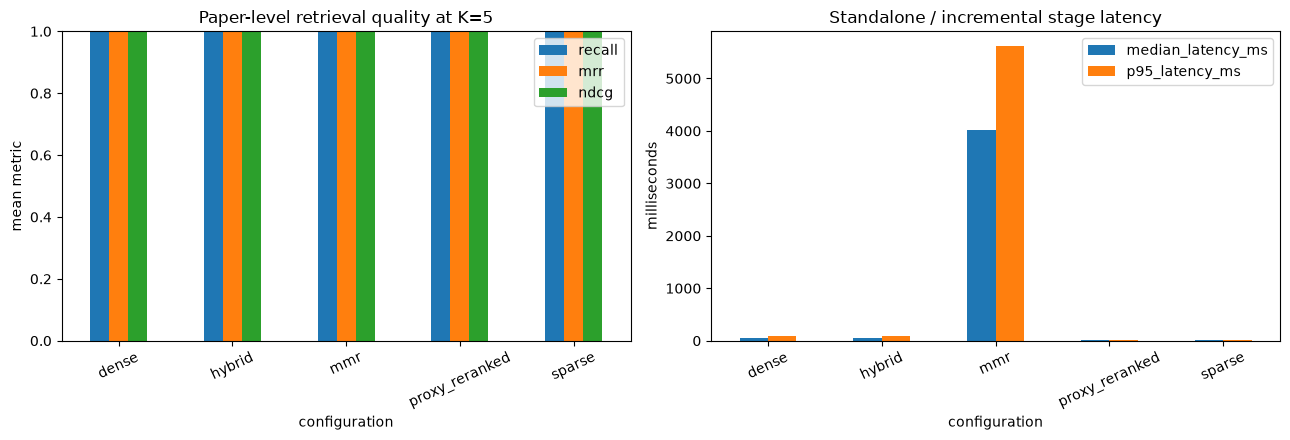

In [8]:
quality_at_5 = aggregate_metrics[aggregate_metrics["k"] == 5].sort_values(["recall", "mrr"], ascending=False)
latency_summary = latency_frame.groupby("configuration", as_index=False).agg(
    median_latency_ms=("latency_ms", "median"),
    p95_latency_ms=("latency_ms", lambda values: values.quantile(0.95)),
)
comparison = quality_at_5.merge(latency_summary, on="configuration", how="left")
display(comparison.style.format({
    "hit": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}", "mrr": "{:.3f}", "ndcg": "{:.3f}",
    "median_latency_ms": "{:.2f}", "p95_latency_ms": "{:.2f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
comparison.set_index("configuration")[["recall", "mrr", "ndcg"]].plot(kind="bar", ylim=(0, 1), ax=axes[0], title="Paper-level retrieval quality at K=5")
axes[0].set_ylabel("mean metric")
axes[0].tick_params(axis="x", rotation=25)
latency_summary.set_index("configuration")[["median_latency_ms", "p95_latency_ms"]].plot(kind="bar", ax=axes[1], title="Standalone / incremental stage latency")
axes[1].set_ylabel("milliseconds")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### 9. Inspect failures and individual rankings

Aggregate metrics can hide query-specific regressions. This table shows the first relevant rank for every query/configuration, followed by a bounded example ranking.

In [9]:
rank_matrix = query_diagnostics.pivot(index="query_id", columns="configuration", values="first_relevant_rank")
display(rank_matrix)

misses_at_5 = query_diagnostics[
    query_diagnostics["first_relevant_rank"].isna() | (query_diagnostics["first_relevant_rank"] > 5)
].copy()
display(misses_at_5[["configuration", "query_id", "first_relevant_rank", "paper_ranking"]])

example_query_id = golden_queries[0]["query_id"]
example_query = golden_queries[0]["query"]
example_rows = []
for configuration, runs in retrieval_runs.items():
    for rank, result in enumerate(runs[example_query_id][:5], 1):
        example_rows.append({
            "configuration": configuration,
            "rank": rank,
            "paper_id": result.paper_id,
            "section": result.section,
            "score": result.score,
            "text": result.text[:120],
        })
print(example_query)
display(pd.DataFrame(example_rows))

configuration,dense,hybrid,mmr,proxy_reranked,sparse
query_id,,,,,
biometric_1,1,1,1,1,1
biometric_2,1,1,1,1,1
dialogue_1,1,1,1,1,1
dialogue_2,1,1,1,1,1
grid_1,1,1,1,1,1
grid_2,1,1,1,1,1
portfolio_1,1,1,1,1,1
portfolio_2,1,1,1,1,1
traffic_1,1,1,1,1,1


,configuration,query_id,first_relevant_rank,paper_ranking


How can traffic video data be used for freeway ramp metering?


,configuration,rank,paper_id,section,score,text
0,dense,1,2012.12104v1,introduction,0.772523,Ramp metering uses traffic signals to regulate vehicle flows from on-ramps to the mainline of th...
1,dense,2,2012.12104v1,methodology,0.662197,the negative impacts of “capacity drop” resulting from massive merging behaviors. The results su...
2,dense,3,2012.12104v1,abstract,0.648739,Ramp metering that uses traffic signals to regulate vehicle flows from the on-ramps has been wid...
3,dense,4,2012.12104v1,introduction,0.648069,monitoring traffic operations and detecting illegal driving behaviors. Compared with point detec...
4,dense,5,2012.12104v1,introduction,0.646727,metering strategy depends on the degree of the fitness of the models to the actual traffic dynam...
5,sparse,1,2012.12104v1,abstract,24.254207,Ramp metering that uses traffic signals to regulate vehicle flows from the on-ramps has been wid...
6,sparse,2,2012.12104v1,introduction,20.823831,videos and learns the optimal control strategies directly from the visual inputs for ramp meteri...
7,sparse,3,2012.12104v1,introduction,20.294856,monitoring traffic operations and detecting illegal driving behaviors. Compared with point detec...
8,sparse,4,2012.12104v1,methodology,20.054836,We propose a DRL method for local ramp metering based on traffic video data. The proposed method...
9,sparse,5,2012.12104v1,introduction,19.702008,metering strategy depends on the degree of the fitness of the models to the actual traffic dynam...


### 10. Validation checks

These checks independently recompute a headline metric, verify evaluation grain and denominators, and explicitly detect ties so the notebook cannot invent a ?best? configuration from non-discriminating quality results.


In [10]:
# Independent Recall@5 recomputation from raw rankings.
manual_recall_at_5 = {}
for configuration, runs in retrieval_runs.items():
    values = []
    for query_id, results in runs.items():
        ranking = unique_paper_ranking(results)[:5]
        values.append(len(set(ranking) & labels_by_query[query_id]) / len(labels_by_query[query_id]))
    manual_recall_at_5[configuration] = float(np.mean(values))

reported_recall_at_5 = quality_at_5.set_index("configuration")["recall"].to_dict()
assert manual_recall_at_5.keys() == reported_recall_at_5.keys()
assert all(np.isclose(manual_recall_at_5[name], reported_recall_at_5[name]) for name in manual_recall_at_5)
assert metrics.groupby(["configuration", "k"]).size().eq(len(golden_queries)).all()
assert query_diagnostics.groupby("configuration")["query_id"].nunique().eq(len(golden_queries)).all()
assert len(chunk_inventory) == chunk_inventory["chunk_id"].nunique()
assert set(chunk_inventory["paper_id"]) == labeled_ids

quality_columns = ["recall", "mrr", "ndcg"]
best_quality = quality_at_5[quality_columns].max()
quality_leaders = quality_at_5[
    quality_at_5[quality_columns].eq(best_quality).all(axis=1)
]["configuration"].tolist()

print("Metric recomputation: PASS")
print("Evaluation grain: one row per query/configuration/K: PASS")
print("Chunk IDs unique and all labeled papers represented: PASS")
if len(quality_leaders) == 1:
    print(f"Diagnostic quality leader at K=5: {quality_leaders[0]}")
else:
    print(f"No unique quality leader at K=5; tied configurations: {quality_leaders}")
    print("Benchmark discrimination check: NEEDS HARDER QUERIES / MORE PAPERS")


Metric recomputation: PASS
Evaluation grain: one row per query/configuration/K: PASS
Chunk IDs unique and all labeled papers represented: PASS
No unique quality leader at K=5; tied configurations: ['dense', 'hybrid', 'mmr', 'proxy_reranked', 'sparse']
Benchmark discrimination check: NEEDS HARDER QUERIES / MORE PAPERS


## Takeaways

- The executed benchmark **cannot distinguish configurations**: every method placed the relevant paper first for all ten queries. Do not select a production retriever from this tie.
- Review labels with a second annotator, add independently written paraphrases, hard negatives, multi-relevant queries, and a larger corpus.
- `proxy_reranked` validates orchestration but does not measure the real MS MARCO cross-encoder. Run this evaluation with that model before judging reranking quality.
- Report latency scopes correctly: reranker and MMR timings here are incremental stage costs; measure cumulative end-to-end latency separately before deployment decisions.
- Paper-level metrics answer ?did we find the right source?? Add chunk-level relevance judgments to test whether the exact supporting passage was retrieved.
- Generation remains unnecessary for retrieval metrics. Add it later for answer correctness, citation accuracy, and faithfulness.
